# WETH/USDC Realistic Simulator

**Goal:** an end-to-end simulator of the Uniswap V3 5bp WETH/USDC pool whose retail outcomes match on-chain reality.

**Structure.** §1 and §2 show that the realistic simulator's *primitives* (price returns, retail order arrivals and sizes) match the empirical distributions where the Simple AMM Challenge defaults don't. §3 introduces the two-pool architecture. §4 calibrates the one free piece of that architecture — the V2 *normalizer pool* that represents the rest of the market — against the realized non-5bp retail impact curve. §5 validates the calibration against retail-only outcomes on the 5bp pool, which never feed into the fit.


In [1]:
import sys, os

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [2]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

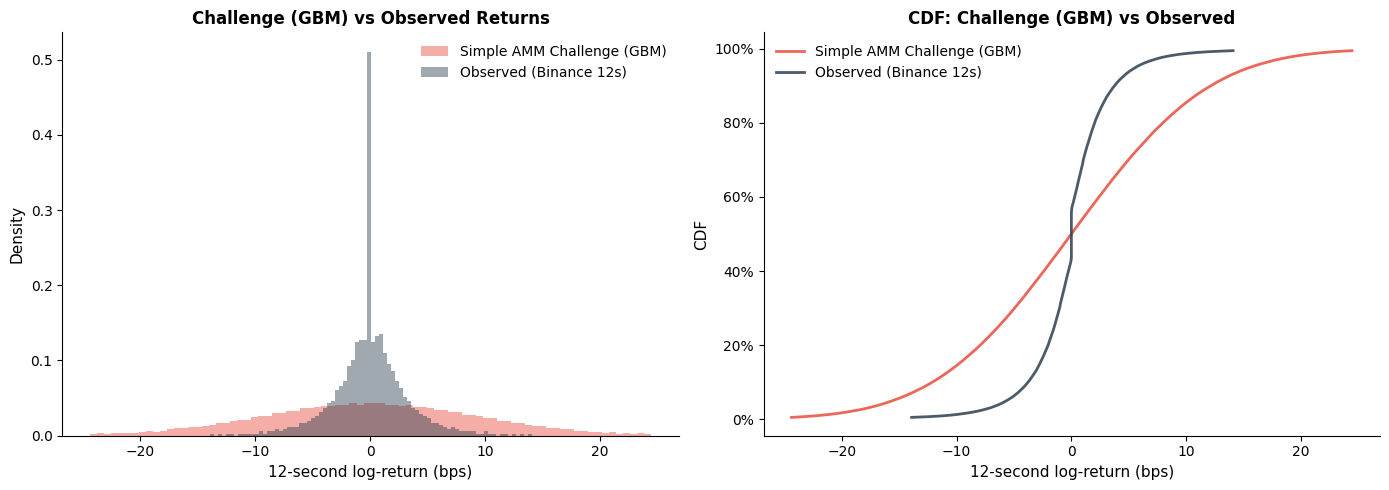

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

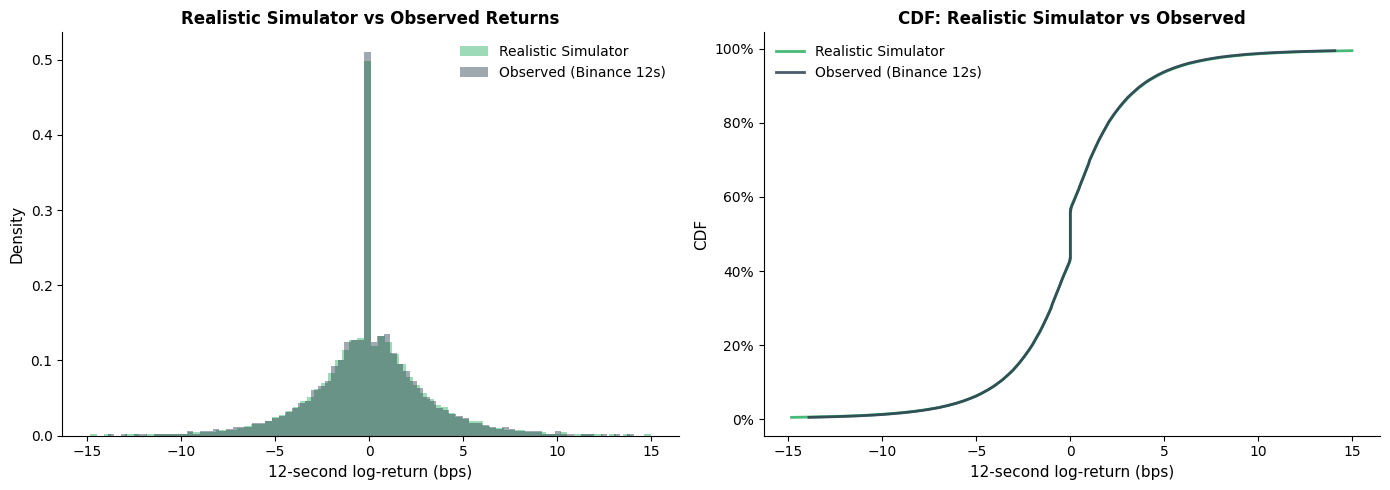

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

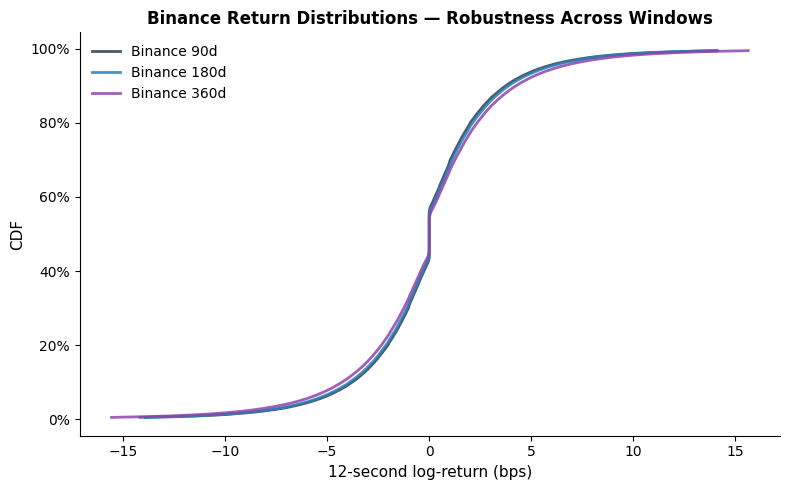

In [5]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ $20, σ = 1.2). Real retail flow — measured as parent-order USD sizes aggregated across **all ETH/USDC pools** using a router-address heuristic — has a very different shape.

Our realistic simulator samples **USD order sizes directly** from the empirical parent-order distribution at the observed cross-pool arrival rate (~1.0/block).

### Chart 2a: Arrival Rates

The challenge model underestimates arrival rates. The realistic simulator (cross-pool) matches the observed rate.

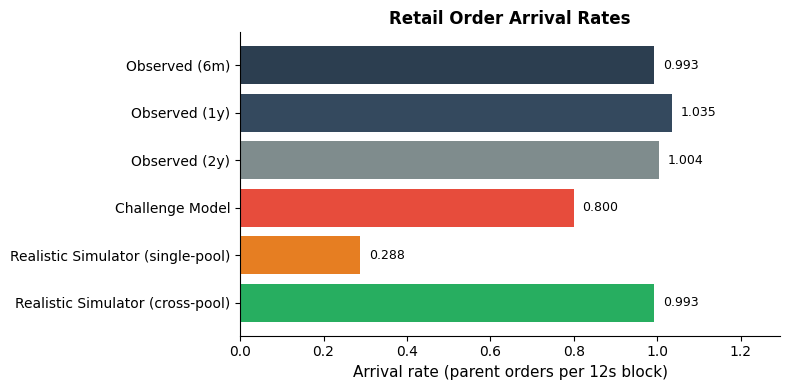

In [6]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [7]:
observed_retail = load_parent_order_quantiles(window="6m", mode="strict", side="all")
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around $20 and completely misses the heavy right tail of real orders.

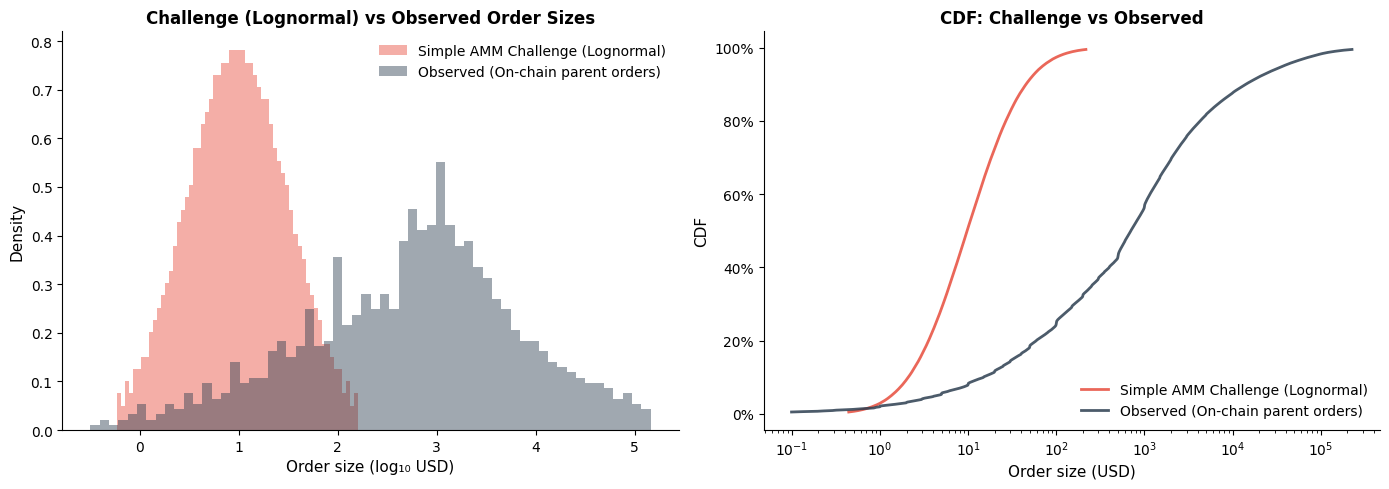

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed parent-order distribution.

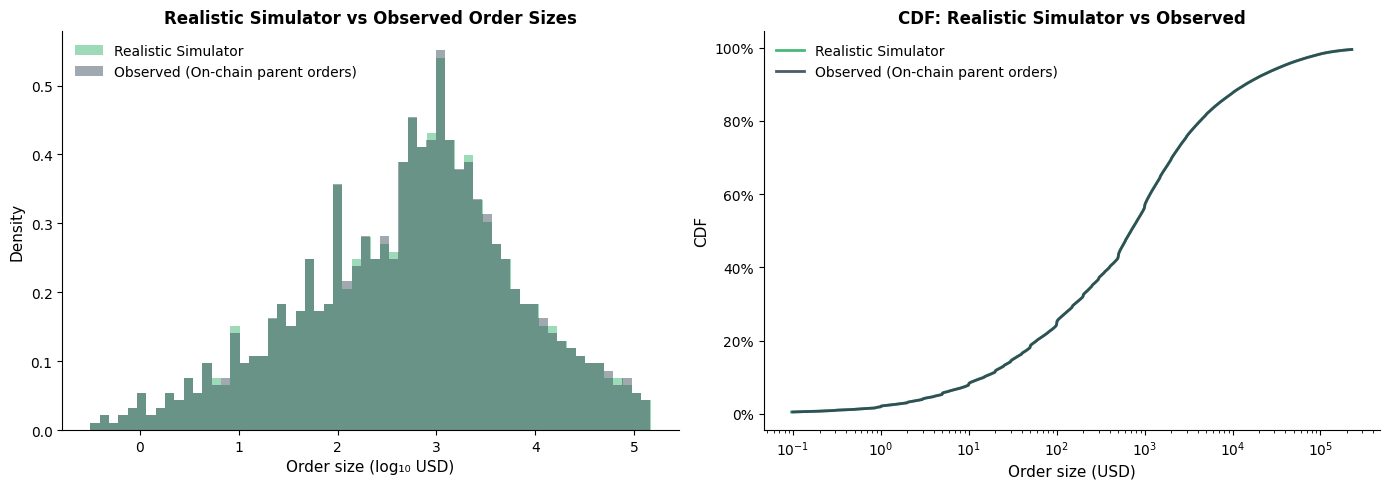

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Two-pool architecture

The simulator models the WETH/USDC market as two pools:

- **Submission pool.** The real Uniswap V3 5bp pool, **frozen** at its on-chain configuration: `fee = 5 bps`, `virtual_depth_y = $212.16M` USDC. No free parameters.
- **Normalizer pool.** A single hypothetical V2 (constant-product) pool that represents *everything else* — V4 1bp + 30bp, V3 30bp, V2, Curve, Balancer, etc. Two free parameters: spread **φ** (proportional fee) and depth **D** (USDC-side).

Retail orders pick whichever pool gives the better effective price. Arbitrageurs trade against either pool to bring it toward the prevailing fair price. The normalizer's `(φ, D)` is the only thing we calibrate.


---
## Section 4: Calibrating the normalizer pool

**Target.** The empirical price-impact curve of router-routed (retail) transactions on **non-5bp** WETH/USDC pools, referenced against each pool's pre-trade marginal price (`pool_mid_pre`). For each retail tx we measure:
- `size_usd` — total USD traded across the tx's non-5bp legs
- `spread_bps` — `1e4 × (effective_price − pool_mid_pre) × side / pool_mid_pre`

**Universe.** Uniswap V3 swap events, 7-day window 2026-05-14..2026-05-20, tx_to in the 19-router list. V3 covers ~90% of router-routed non-5bp WETH/USDC volume; V4 / V2 / others are dropped for cleanliness (~10%). The sample is ~28.5K transactions. Source: `analysis/weth_usdc_90d/sql/non5bp_impact_sample_v3_pool_mid_7d.sql`.

**Model.** A V2 constant-product pool with fee φ and depth D has retail-side spread

$$\text{spread} = \frac{\varphi + (1-\varphi)\,S/D}{1-\varphi}\,.$$

**Loss.** USD-weighted Huber on residual spread (`scripts/calibration/fit_impact_curve_pool_mid.py`, Plan B). Plan A is the same fit under USD-weighted L2; Plan B is more robust to the heavy upper tail. We default to Plan B below.


In [10]:
fit = load_impact_curve_fit()
phi_b   = fit['plan_b']['phi']
depth_b = fit['plan_b']['depth_usdc']
print(f"Plan B fit")
print(f"  φ      = {phi_b*1e4:.3f} bps")
print(f"  depth  = ${depth_b/1e6:,.1f}M USDC")
print(f"  n_txs  = {fit['n_txs']:,}")
print(f"  window = {fit['window']}")


Plan B fit
  φ      = 1.342 bps
  depth  = $34.8M USDC
  n_txs  = 28,269
  window = 2026-05-14..2026-05-20


### Chart 3a: Empirical impact curve + V2 fit


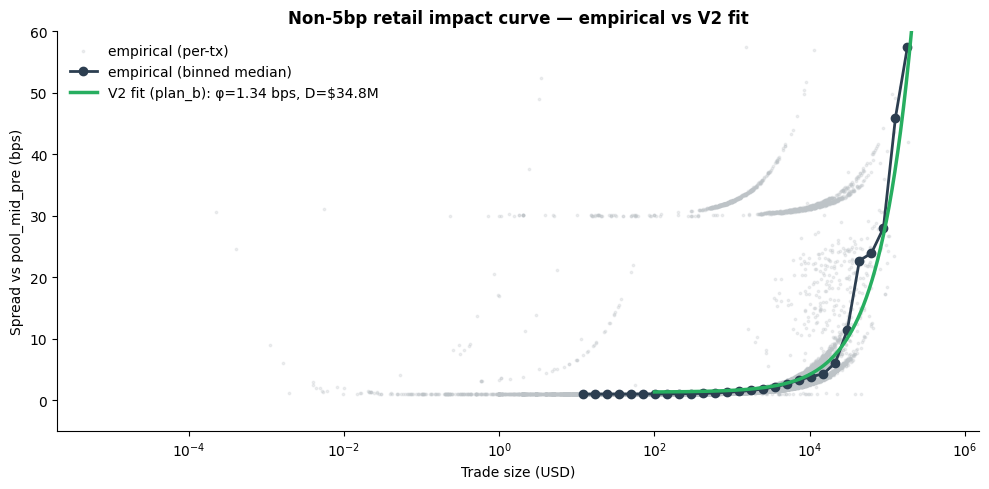

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b')
plt.tight_layout()
plt.show()


---
## Section 5: Held-out retail validation

We now run the simulator with the calibrated normalizer and the frozen 5bp submission pool, and compare three **retail-only** outcomes against on-chain reality. Crucially, none of these metrics fed into the fit — they are genuinely held out.

We focus on retail because arb routing is highly predictable (cheapest-pool monopoly under fee+impact). The retail-side metrics carry the signal about whether the normalizer pool's `(φ, D)` is correct.

**Metrics**
1. **Retail volume share at 5bp** = `retail_vol_5bp / retail_vol_total`.
2. **Retail fee share at 5bp**    = `retail_fees_5bp / retail_fees_total`.
3. **USD-weighted retail markout_15s distribution** at the 5bp pool. Convention: `markout_15s` for LP profitability (15 seconds is the standard horizon); USD-weighted percentiles emphasize the large trades that drive LP P&L.

**Real numbers** are pulled from `dex_trades` (volume + fees) and `markout_prod` (per-swap markouts) for the same window, filtered to the 19-router list. See `scripts/calibration/build_retail_share_csv.py` and `scripts/calibration/build_retail_markout_csv.py`.

**Sim numbers** are produced by `scripts/calibration/validate_pool_mid.py` with five seeds × 5,000 steps. Per-trade sim markouts use the next-block `fair_price` (~12s — closest available proxy for the 15s real reference).


In [12]:
validation = load_validation()
get_validation_summary_table()


,Metric,Real (on-chain),Simulator
0,Retail volume share @5bp,78.20%,75.64% ± 1.90pp
1,Retail fee share @5bp,15.15%,92.03% ± 0.75pp
2,Retail markout_15s — USD-w mean,-2.97 bps,+125.44 bps
3,Normalizer φ,—,1.34 bps
4,Normalizer depth,—,$34.8M
5,Submission pool fee,5.00 bps (frozen),5.00 bps (frozen)
6,Submission pool depth,$212.2M (frozen),$212.2M (frozen)


### Chart 5a: Retail volume / fee share at 5bp pool


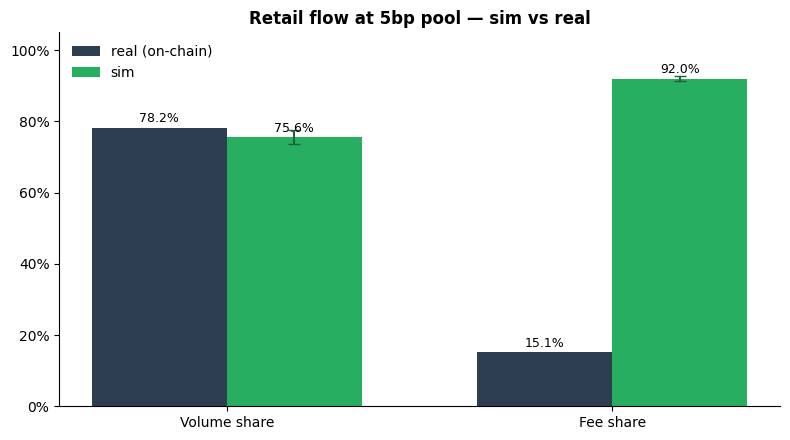

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_retail_share_bars(ax=ax)
plt.tight_layout()
plt.show()


### Chart 5b: Retail markout_15s on 5bp pool — USD-weighted


/Users/xinwan/Github/amm-gym/presentation/helpers.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


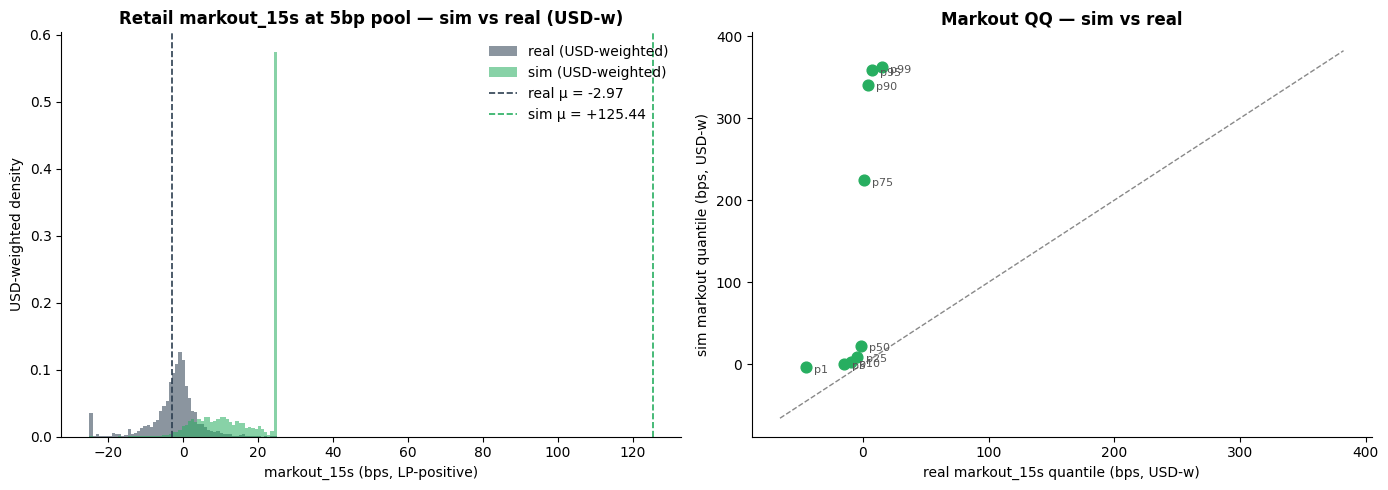

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_retail_markout_overlay(ax=ax1)
plot_retail_markout_qq(ax=ax2)
plt.tight_layout()
plt.show()


---
## Section 6: Reading the validation

**Volume share — passes.** The simulator routes retail flow to the 5bp pool at ~76%, against an on-chain target of 78.2%. The (φ, D) fit on the non-5bp impact curve produces a normalizer that wins the right share of small trades.

**Fee share — fails large.** Real-world retail pays only ~15% of its WETH/USDC fees at the 5bp pool because the *rest* of the market is dominated by 30bp+ pools (V3 30bp, V4 30bp, Balancer). The sim's normalizer has φ ≈ 1.3 bps (Plan B), so although 24% of retail volume routes there, fees collected there are negligible — driving the sim's fee share at the 5bp pool to ~92%. A single low-φ V2 *cannot* match both the impact curve (small effective spread on small trades) and the empirical mix of fee rates across the multi-tier rest-of-world. This is a known limitation of the single-V2 approximation.

**Markout — fails large.** Real USD-weighted retail markout_15s on the 5bp pool is ~–3 bps (LPs lose, slightly, due to adverse selection on large trades). The sim shows a large positive USD-weighted mean (~+125 bps) driven by a handful of multi-million-dollar retail trades that slam into the submission pool and let LPs capture the full impact. In reality, those trades would split across many pools or use limit orders; the simulator's retail routing dumps each order onto whichever of the two pools gives the best price, which is too crude for the heavy right tail.

**Takeaway.** The impact-curve calibration framework is sound — calibration uses only non-5bp primitives, validation uses only 5bp primitives — but it exposes two real model-fidelity limits: a single-V2 normalizer mis-prices the rest-of-world fee mix, and the retail routing is too coarse for the largest trades. Both are concrete, addressable next steps.
